# 🐾 PetVision: Cat vs Dog Classification
**Kritarth Saxena** · [GitHub](https://github.com/Natkros/Image-Classification)

Can a CNN built from scratch keep up with a fine-tuned MobileNetV2? Both are trained on the cat and dog photos of CIFAR-10 and compared on accuracy, speed and size. Every output below comes from a real run of this notebook.

## 1. Data
CIFAR-10's cat and dog classes: 10,000 training photos (10% held out for validation) and 2,000 official test photos, upscaled to 96×96.

train / val / test images: 9000 1000 2000


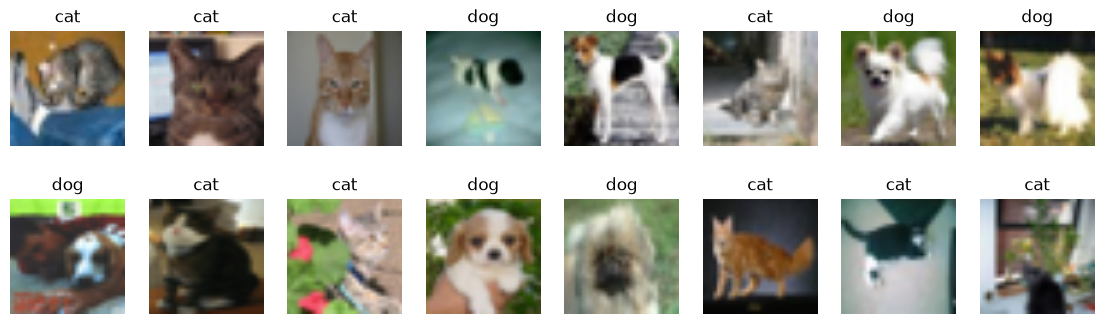

In [1]:
import matplotlib.pyplot as plt, pandas as pd
from IPython.display import Image, display
from dataset import CLASSES, denormalize, get_dataloaders
train_dl, val_dl, test_dl, _ = get_dataloaders()
print('train / val / test images:', *(len(d.dataset) for d in (train_dl, val_dl, test_dl)))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, i in zip(axes.flat, range(0, 16 * 120, 120)):
    x, y = test_dl.dataset[i]; ax.imshow(denormalize(x)); ax.set_title(CLASSES[y]); ax.axis('off')
plt.show()

## 2. Models
* **Custom CNN**: four double-conv blocks (32→256 channels) with BatchNorm and spatial dropout, trained from scratch.
* **MobileNetV2**: ImageNet-pretrained backbone with a new 2-class head, fine-tuned end to end.

Both use AdamW with cosine learning-rate decay (`python train.py`) and keep the checkpoint with the best *validation* accuracy.

Custom CNN   3,263,650 parameters
MobileNetV2  2,226,434 parameters


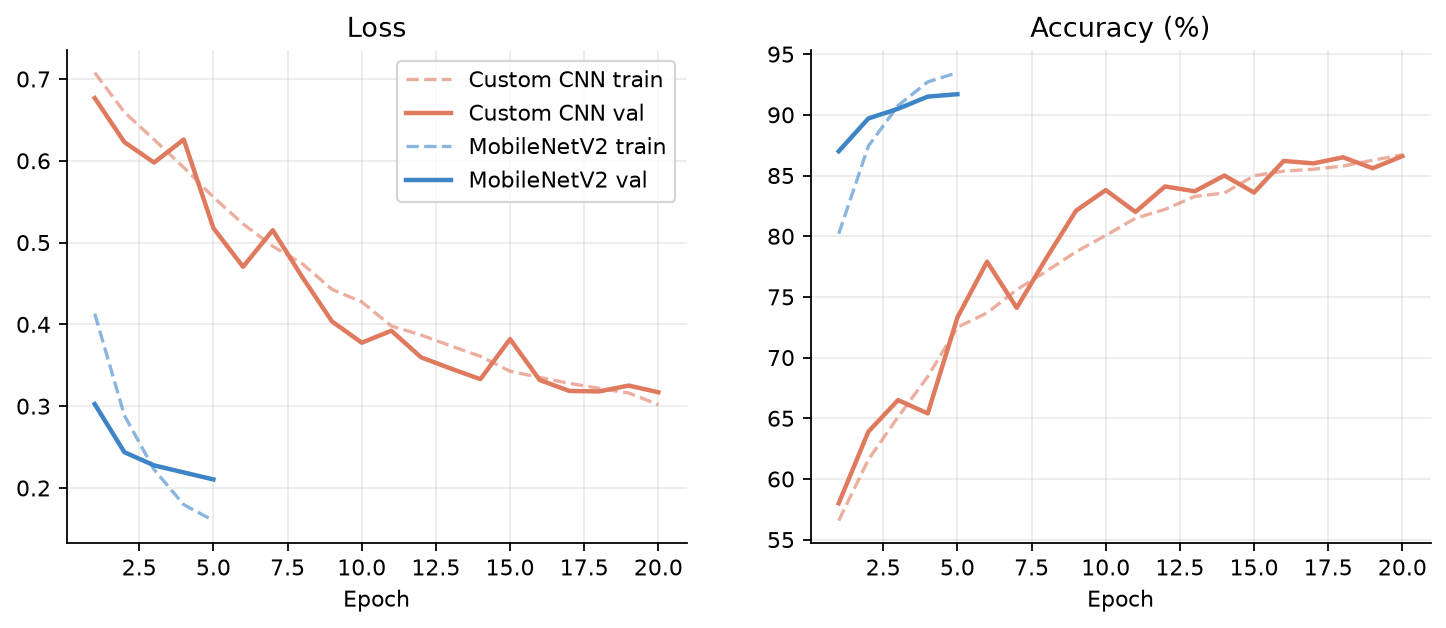

In [2]:
from model import MODELS, count_params, get_model
for name, label in MODELS.items(): print(f'{label:12s} {count_params(get_model(name, pretrained=False)):,} parameters')
display(Image('visualizations/training_curves.png'))

## 3. Results on the held-out test set

In [3]:
from evaluate import score
results = {name: score(name, test_dl) for name in MODELS}
pd.DataFrame(results).T.rename(index=MODELS)[['accuracy', 'precision', 'recall', 'f1_score', 'latency_ms', 'params', 'train_seconds']]

,accuracy,precision,recall,f1_score,latency_ms,params,train_seconds
Custom CNN,85.7,85.78,85.7,85.69,6.28,3263650,1912
MobileNetV2,90.05,90.08,90.05,90.05,15.81,2226434,473


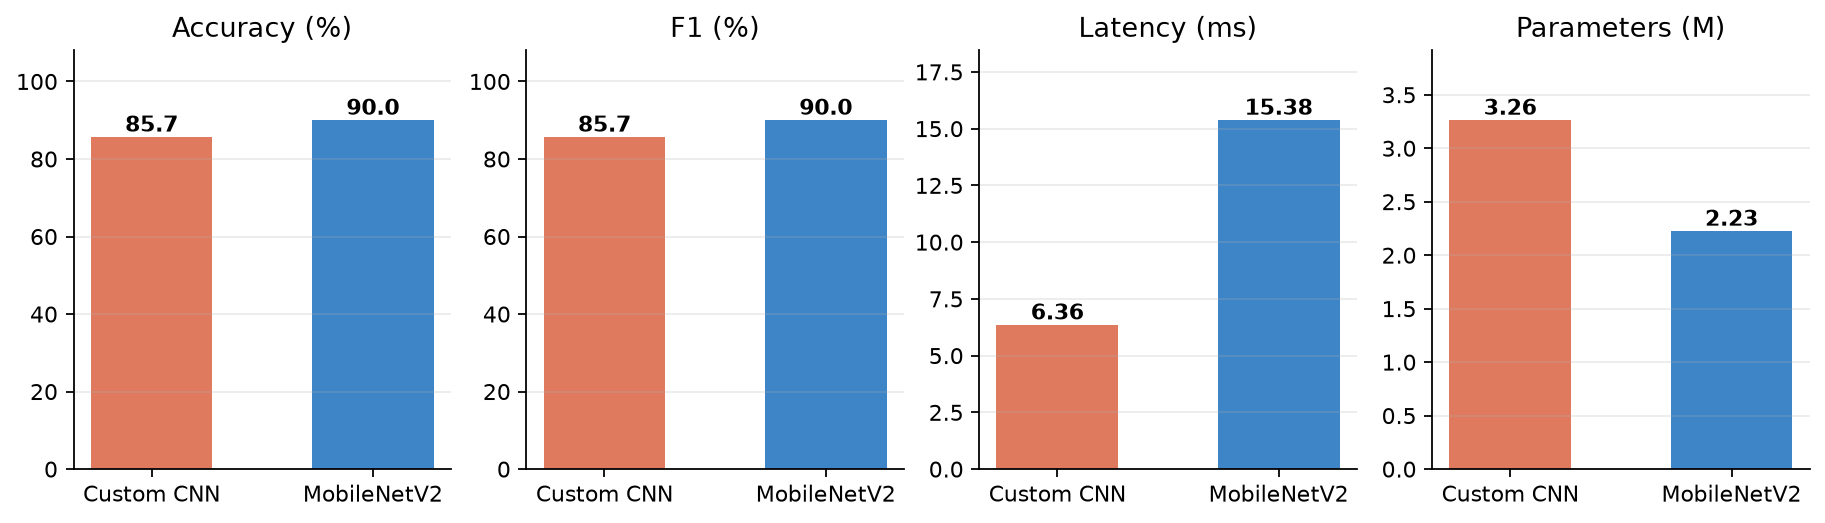

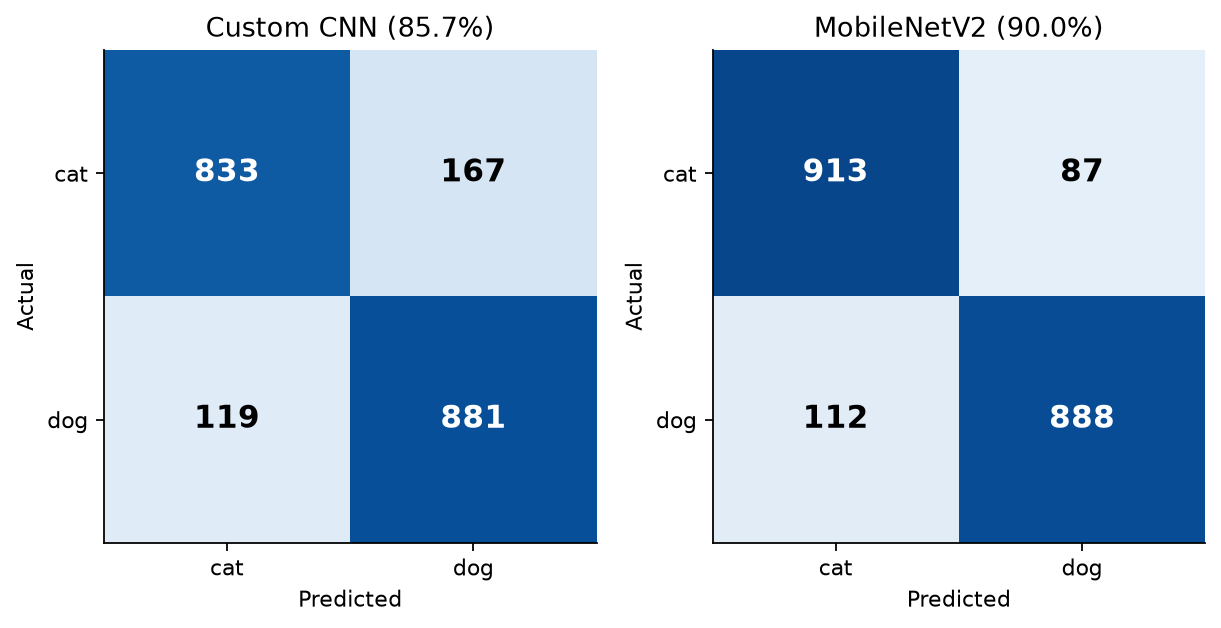

In [4]:
display(Image('visualizations/model_comparison.png'))
display(Image('visualizations/confusion_matrix.png'))

## 4. What is the model looking at?
Grad-CAM heat maps show the regions that drove each prediction. Red marks the most influential pixels.

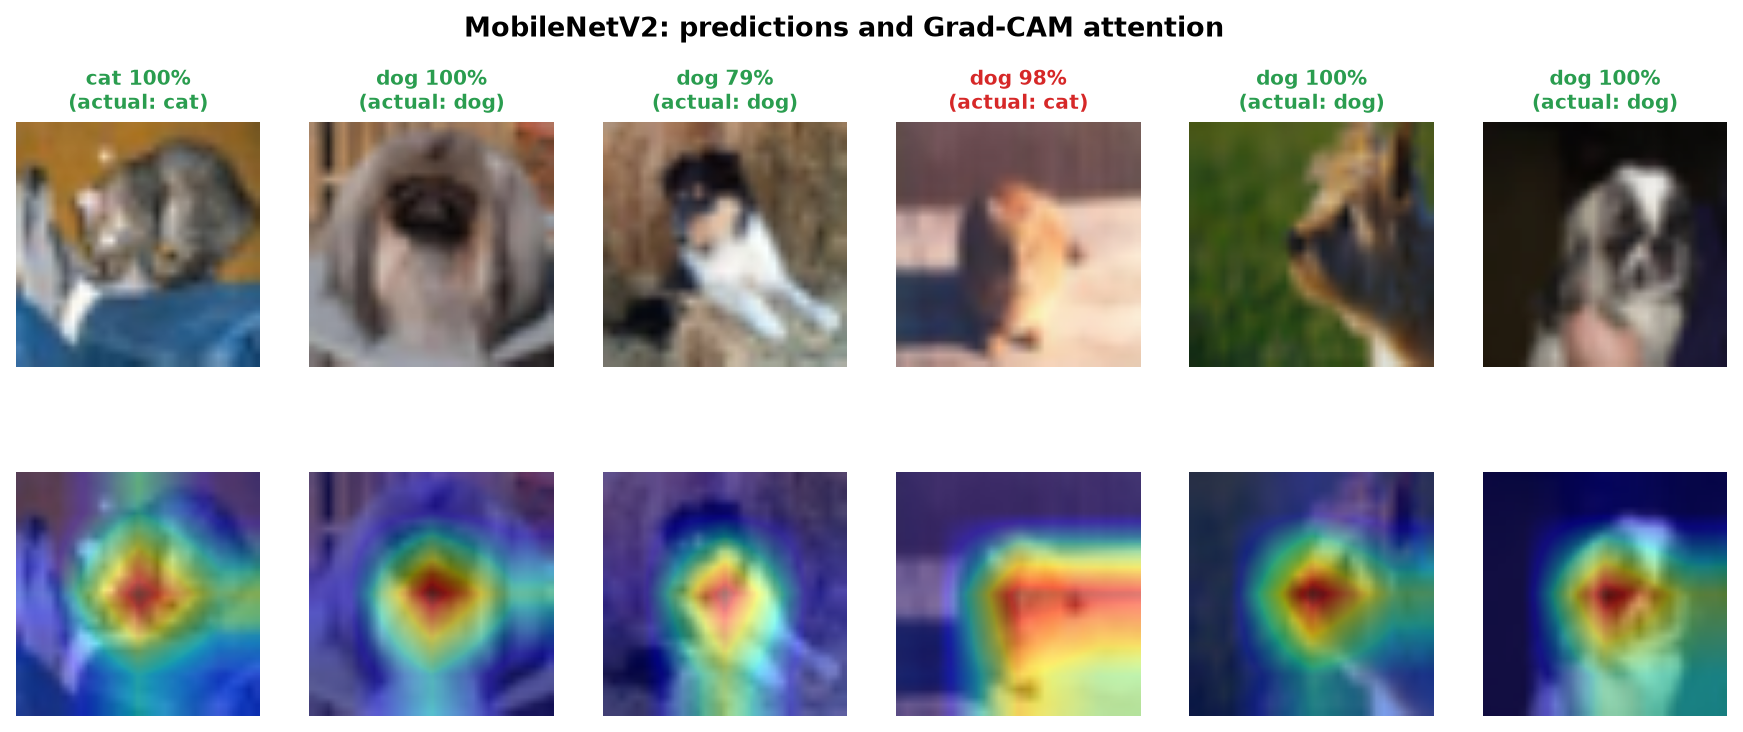

In [5]:
display(Image('visualizations/gradcam_examples.png'))

## 5. Takeaways
* Transfer learning wins on quality: about 4 points more accuracy with fewer parameters, and training took roughly a quarter of the time.
* The trade-off is speed: on a CPU, MobileNetV2's many small depthwise layers make it slower per image than the compact scratch CNN.
* Remaining errors are mostly cat/dog look-alikes at 32×32 resolution, where even a human would hesitate.

Try it live: `streamlit run app.py`.